# Entrega 2: Análisis Exploratorio de Datos (EDA)
**Materia:** Análisis de Datos 
**Alumno:** Agustin Ross  
**Dataset:** Transacciones Bancarias

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

In [2]:
url = "https://raw.githubusercontent.com/agustinross-ar/MIA_ADatos/main/Entrega_Individual_2/bank_transactions_data_2_augmented_clean_2.csv"
df = pd.read_csv(url)
print(f"✅ Dataset cargado. Dimensiones: {df.shape}")

✅ Dataset cargado. Dimensiones: (50000, 15)


# 1. Inspección Inicial del Dataset
En esta fase realizamos una primera aproximación a los datos para entender su estructura, dimensiones y los tipos de variables definidos por Pandas.

In [ ]:
# 1.1 Vista rápida
print("--- PRIMERAS 5 FILAS ---")
display(df.head())

# 1.2 Estructura y Tipos
print("\n--- INFORMACIÓN GENERAL Y DTYPES ---")
df.info()


--- PRIMERAS 5 FILAS ---


,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,TX000001,AC00128,14.09,4/11/2023 16:29,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21
1,TX000002,AC00455,376.24,6/27/2023 16:44,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91
2,TX000003,AC00019,126.29,7/10/2023 18:16,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35
3,TX000004,AC00070,184.50,5/5/2023 16:32,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06
4,TX000005,AC00411,13.45,10/16/2023 17:51,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40



--- INFORMACIÓN GENERAL Y DTYPES ---
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   TransactionID        50000 non-null  str    
 1   AccountID            50000 non-null  str    
 2   TransactionAmount    50000 non-null  float64
 3   TransactionDate      50000 non-null  str    
 4   TransactionType      50000 non-null  str    
 5   Location             50000 non-null  str    
 6   DeviceID             50000 non-null  str    
 7   IP Address           50000 non-null  str    
 8   MerchantID           50000 non-null  str    
 9   Channel              50000 non-null  str    
 10  CustomerAge          50000 non-null  int64  
 11  CustomerOccupation   50000 non-null  str    
 12  TransactionDuration  50000 non-null  int64  
 13  LoginAttempts        50000 non-null  int64  
 14  AccountBalance       50000 non-null  float64
dtypes: float6

# 2. Diagnóstico de Calidad de Datos
Evaluamos la integridad del dataset buscando valores faltantes y registros duplicados. También analizamos la cardinalidad de las variables categóricas para entender la diversidad de los datos.

In [ ]:
# 2.1 Identificación de Nulos
print("--- VALORES FALTANTES POR COLUMNA ---")
nulos_cantidad = df.isnull().sum()
nulos_porcentaje = (df.isnull().sum() / len(df)) * 100
calidad_datos = pd.DataFrame({'Cantidad Nulos': nulos_cantidad, 'Porcentaje (%)': nulos_porcentaje})
print(calidad_datos[calidad_datos['Cantidad Nulos'] > 0].sort_values(by='Porcentaje (%)', ascending=False))

# 2.2 Identificación de Filas Duplicadas
duplicados = df.duplicated().sum()
print(f"\n--- FILAS DUPLICADAS IDENTIFICADAS: {duplicados} ---")

# 2.3 Verificación de Cardinalidad
print("\n--- CARDINALIDAD DE VARIABLES CUALITATIVAS ---")
# Seleccionamos solo las columnas categóricas
columnas_categ_df = df.select_dtypes(include=['object'])
for col in columnas_categ_df.columns:
    print(f"{col}: {df[col].nunique()} valores únicos")

--- VALORES FALTANTES POR COLUMNA ---
Empty DataFrame
Columns: [Cantidad Nulos, Porcentaje (%)]
Index: []

--- FILAS DUPLICADAS IDENTIFICADAS: 0 ---

--- CARDINALIDAD DE VARIABLES CUALITATIVAS ---
TransactionID: 50000 valores únicos
AccountID: 495 valores únicos
TransactionDate: 6373 valores únicos
TransactionType: 2 valores únicos
Location: 43 valores únicos
DeviceID: 681 valores únicos
IP Address: 592 valores únicos
MerchantID: 100 valores únicos
Channel: 3 valores únicos
CustomerOccupation: 4 valores únicos


C:\Users\ROA22468\AppData\Local\Temp\ipykernel_18696\3862593302.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columnas_categ_df = df.select_dtypes(include=['object'])


# 3. Análisis Estadístico y Univariado
Calculamos las métricas de tendencia central y dispersión. Visualizamos la distribución de las variables clave (Monto y Edad) mediante histogramas para observar su forma y boxplots para identificar potenciales outliers.

--- ANÁLISIS ESTADÍSTICO INICIAL ---


,TransactionAmount,CustomerAge,AccountBalance
count,50000.000000,50000.000000,50000.000000
mean,297.872214,44.647600,5122.738301
std,292.818888,17.800293,3904.266887
min,0.240000,18.000000,101.250000
25%,82.897500,27.000000,1508.720000
50%,209.355000,45.000000,4735.410000
75%,409.625000,59.000000,7713.670000
max,2060.590000,80.000000,14977.990000


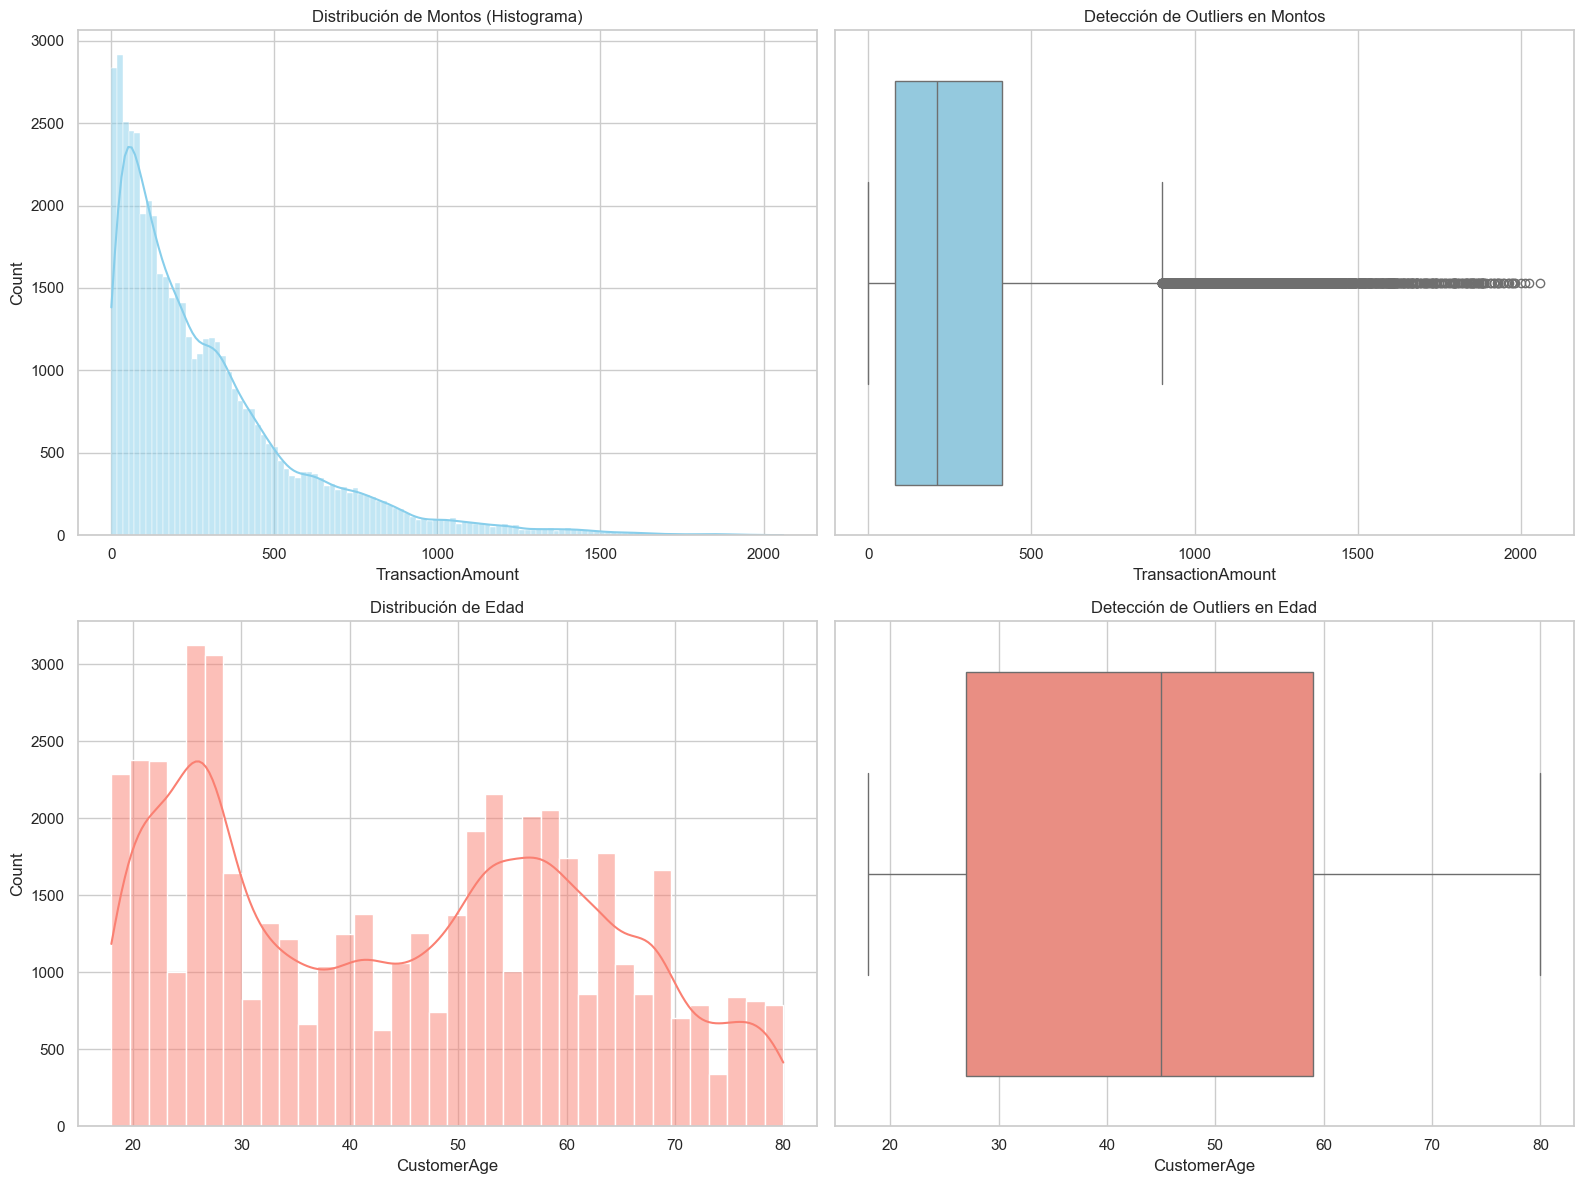

In [ ]:
# 1. Estadísticas Descriptivas
print("--- ANÁLISIS ESTADÍSTICO INICIAL ---")
# Métricas de tendencia central y dispersión
display(df[['TransactionAmount', 'CustomerAge', 'AccountBalance']].describe())

# 2. Configuración del Gráfico Múltiple (EDA Univariado)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- FILA 0: TRANSACCIONES (Análisis de Montos) ---
# Histograma con KDE para ver la forma de la distribución
sns.histplot(df['TransactionAmount'], kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Distribución de Montos (Histograma)')

# Boxplot para identificar Outliers
sns.boxplot(x=df['TransactionAmount'], ax=axes[0, 1], color='skyblue')
axes[0, 1].set_title('Detección de Outliers en Montos')

# --- FILA 1: CLIENTES (Análisis de Edad) ---
# Histograma de Edad
sns.histplot(df['CustomerAge'], kde=True, ax=axes[1, 0], color='salmon')
axes[1, 0].set_title('Distribución de Edad')

# Boxplot de Edad
sns.boxplot(x=df['CustomerAge'], ax=axes[1, 1], color='salmon')
axes[1, 1].set_title('Detección de Outliers en Edad')

plt.tight_layout()
plt.show() 

# 4. Análisis Bivariado y Correlaciones
Exploramos la relación entre la edad de los clientes y los montos transaccionados, y analizamos la matriz de correlación para identificar dependencias entre las variables numéricas del sistema.

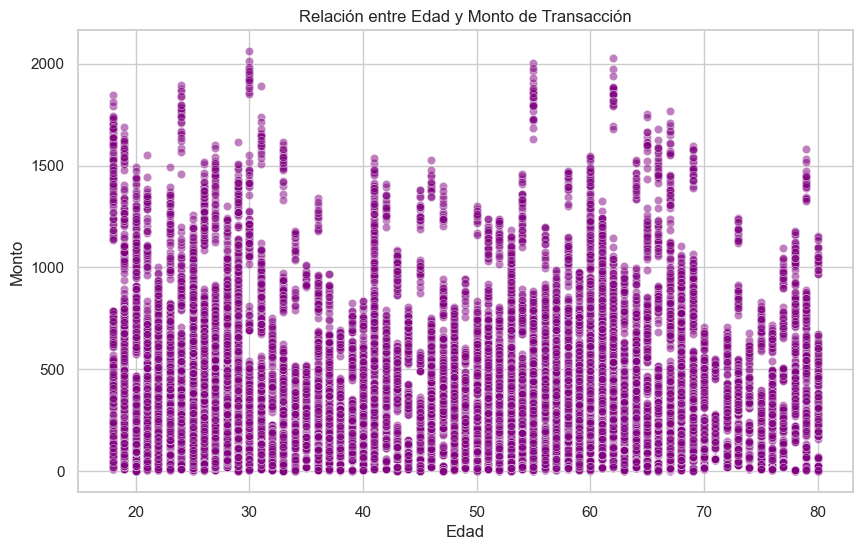


--- MATRIZ DE CORRELACIÓN ---


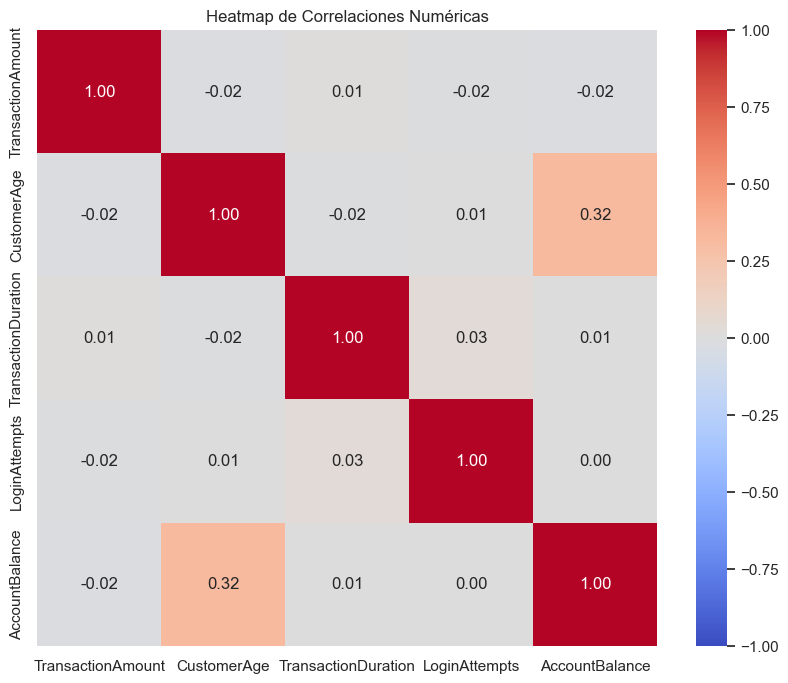

In [ ]:
# 1. Scatterplot: Edad vs Monto
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='CustomerAge', y='TransactionAmount', alpha=0.5, color='purple')
plt.title('Relación entre Edad y Monto de Transacción')
plt.xlabel('Edad')
plt.ylabel('Monto')
plt.show()

# 2. Matriz de Correlación
# Solo para columnas numéricas
print("\n--- MATRIZ DE CORRELACIÓN ---")
columnas_numericas = df.select_dtypes(include=[np.number])
corr_matrix = columnas_numericas.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Heatmap de Correlaciones Numéricas')
plt.show()

# 5. Segmentación por Tipo de Transacción
Finalmente, analizamos cómo se distribuyen los montos de acuerdo al tipo de transacción realizada (Debit/Credit/etc), buscando patrones de comportamiento específicos por categoría.

C:\Users\ROA22468\AppData\Local\Temp\ipykernel_18696\1583104242.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='TransactionType', y='TransactionAmount', palette='Set2')


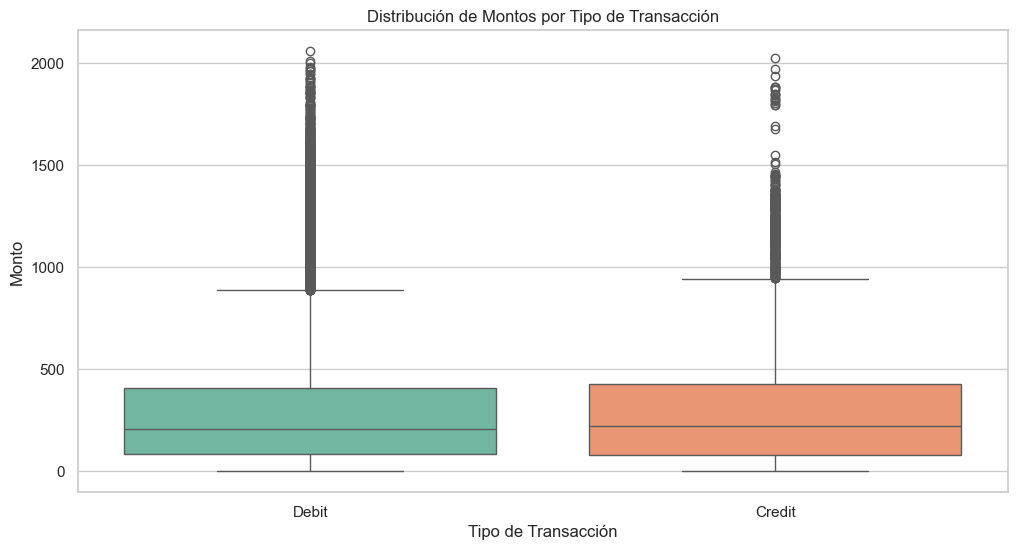

In [7]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='TransactionType', y='TransactionAmount', palette='Set2')
plt.title('Distribución de Montos por Tipo de Transacción')
plt.xlabel('Tipo de Transacción')
plt.ylabel('Monto')
plt.show()